# H1N1 抗原距离结果

读取 `outputs/h1n1_antigenicity` 的 7-GPU 推理结果，并按冻结血清面板、时间窗口与 Nextclade 分支汇总。主分数为一条病毒相对截止日前全部血清条件的平均预测抗原距离；数值越大表示模型预测的抗原距离越远。

> 说明：同一序列可在相邻的多个预测截止点重复评分，因此评分表与原始序列表是**多对一**关联。

In [1]:
from pathlib import Path
import sqlite3
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path('/home/chenyh/workspace/Alright-strain')
OUT = ROOT / 'outputs' / 'h1n1_antigenicity'
DB = OUT / 'antigenicity_scores.sqlite'
sys.path.insert(0, str(ROOT))

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)

## 1. 读取结果与完成性检查

In [2]:
identity = ['fasta_sha256', 'sequence_index', 'sequence_sha256']
with sqlite3.connect(DB) as con:
    scores = pd.read_sql_query('SELECT * FROM query_summary', con)
    n_pairs = pd.read_sql_query('SELECT COUNT(*) AS n_pair_scores FROM pair_scores', con).iloc[0, 0]
instances = pd.read_csv(OUT / 'input' / 'query_instances.csv', usecols=[*identity, 'full_header', 'collection_date'])
cutoffs = pd.read_csv(OUT / 'panels' / 'forecast_cutoffs.csv')

# 每条 score 只有一个原始 query；同一 query 可出现于多个 forecast_cutoff。
scores = scores.merge(instances, on=identity, how='left', validate='many_to_one')
scores['collection_date'] = pd.to_datetime(scores['collection_date'], errors='coerce')
assert scores['full_header'].notna().all(), '存在无法关联到原始序列的评分记录'

coverage = (scores.groupby('forecast_cutoff', as_index=False)
    .agg(query_summaries=('query_id', 'size'), unique_queries=('query_id', 'nunique'),
         panel_size=('panel_size', 'first'), mean_distance=('mean_distance', 'mean'),
         score_time=('scored_at_utc', 'max'))
    .merge(cutoffs[['forecast_cutoff', 'annual_query_instances', 'frozen_serum_conditions']], on='forecast_cutoff'))
coverage['complete'] = coverage.query_summaries.eq(coverage.annual_query_instances)
coverage['mean_distance'] = coverage['mean_distance'].round(3)

print(f'{len(scores):,} query summaries | {n_pairs:,} serum–virus pair scores | {scores.forecast_cutoff.nunique()} cutoffs')
display(coverage)
assert coverage.complete.all(), '至少一个截止点的年度查询评分未完成'

42,738 query summaries | 2,965,570 serum–virus pair scores | 9 cutoffs


,forecast_cutoff,query_summaries,unique_queries,panel_size,mean_distance,score_time,annual_query_instances,frozen_serum_conditions,complete
0,2021-09-30,591,507,56,2.389,2026-10-04T12:10:35.862701+00:00,591,56,True
1,2022-03-31,898,731,59,2.374,2026-10-04T12:13:31.289306+00:00,898,59,True
2,2022-09-30,1235,951,62,2.380,2026-10-04T12:14:06.879930+00:00,1235,62,True
3,2023-03-31,3429,2330,65,2.510,2026-10-04T12:15:33.759737+00:00,3429,65,True
4,2023-09-30,4771,3167,65,2.547,2026-10-04T12:18:20.185301+00:00,4771,65,True
5,2024-03-31,7195,4705,67,2.418,2026-10-04T12:22:18.469825+00:00,7195,67,True
6,2024-09-30,7321,4657,67,2.409,2026-10-04T12:26:00.381271+00:00,7321,67,True
7,2025-03-31,8561,5507,75,2.232,2026-10-04T12:30:29.955775+00:00,8561,75,True
8,2025-09-30,8737,5603,75,2.176,2026-10-04T12:34:57.439678+00:00,8737,75,True


## 2. 各冻结血清面板下的距离分布

面板随时间扩大，跨截止点的绝对值受血清组成影响；更适合比较同一截止点内的分支相对距离。

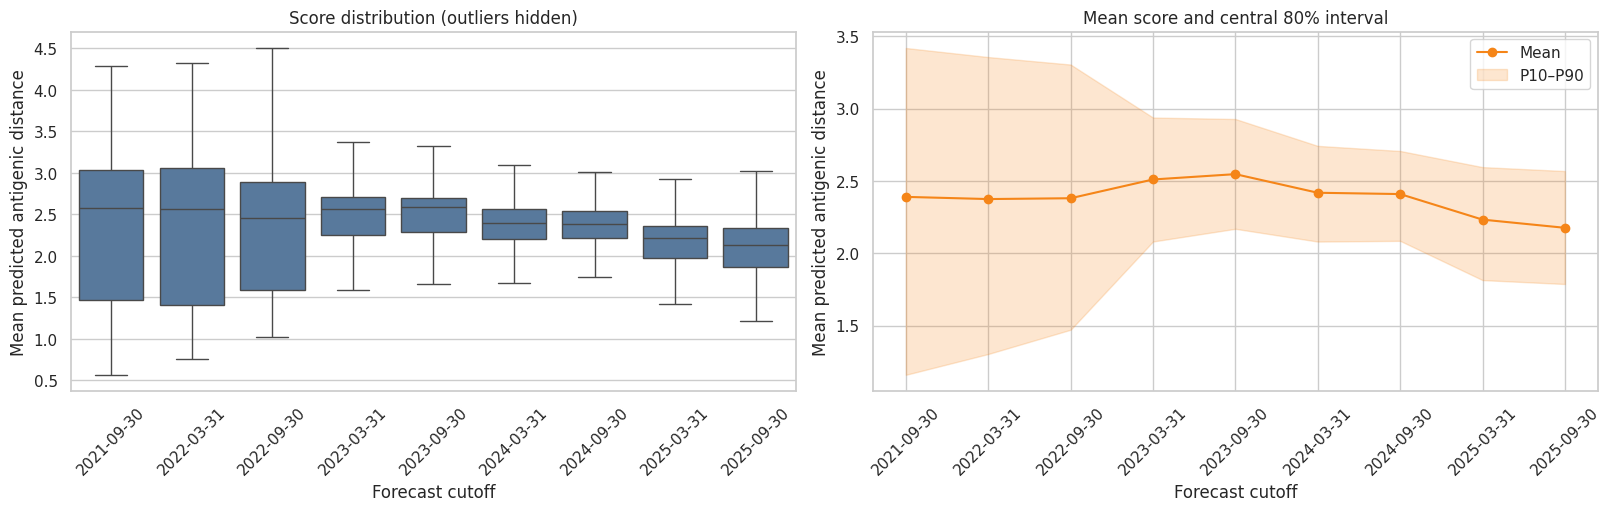

In [3]:
order = cutoffs['forecast_cutoff'].astype(str).tolist()
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
sns.boxplot(data=scores, x='forecast_cutoff', y='mean_distance', order=order, showfliers=False, color='#4C78A8', ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set(xlabel='Forecast cutoff', ylabel='Mean predicted antigenic distance', title='Score distribution (outliers hidden)')
summary = scores.groupby('forecast_cutoff')['mean_distance'].agg(mean='mean', p10=lambda s: s.quantile(.1), p90=lambda s: s.quantile(.9)).reindex(order)
axes[1].plot(order, summary['mean'], marker='o', color='#F58518', label='Mean')
axes[1].fill_between(range(len(order)), summary['p10'], summary['p90'], color='#F58518', alpha=.2, label='P10–P90')
axes[1].set_xticks(range(len(order)), order, rotation=45)
axes[1].set(xlabel='Forecast cutoff', ylabel='Mean predicted antigenic distance', title='Mean score and central 80% interval')
axes[1].legend()
plt.show()

## 3. 滚动窗口：抗原距离与后续分支占比

对于每个截止点，定义 escape excess 为“最近半年该分支的平均距离 − 该截止点年度总体平均距离”。只保留近期至少有 10 条已评分序列的分支。后续占比变化来自 Nextclade 记录；这是预测关联回测，不代表因果适应度。

In [4]:
from src.h1n1_subclade_plot import read_nextclade_table

nextclade_path = ROOT / 'data' / 'raw' / 'nextclade' / 'H1N1' / 'h1n1_results_MW626062_sorted.tsv'
records = read_nextclade_table(nextclade_path, label_mode='nextclade')
records['epi_isl'] = records['seqName'].astype('string').str.extract(r'\|(EPI_ISL_\d+)\|', expand=False)
records = records.loc[records['epi_isl'].notna() & ~records['epi_isl'].duplicated(keep=False)].copy()
scores['epi_isl'] = scores['full_header'].astype('string').str.extract(r'\|(EPI_ISL_\d+)\|', expand=False)

def top(series):
    series = series.dropna()
    return None if series.empty else series.sort_values(ascending=False, kind='stable').index[0]

details, metric_rows = [], []
for window in cutoffs.itertuples(index=False):
    cutoff = str(window.forecast_cutoff)
    annual_scores = scores.loc[(scores.forecast_cutoff.eq(cutoff)) & scores.collection_date.between(window.annual_start, window.annual_end)].copy()
    annual = annual_scores.merge(records[['epi_isl', 'collection_date', 'prediction_branch']], on='epi_isl', how='inner', suffixes=('_asset', '_nextclade'), validate='many_to_one')
    annual['collection_date_nextclade'] = pd.to_datetime(annual['collection_date_nextclade'], errors='coerce')
    recent = annual.loc[annual.collection_date_nextclade.between(window.recent_start, window.recent_end)]
    current_all = records.loc[records.collection_date.between(window.recent_start, window.recent_end)]
    target_all = records.loc[records.collection_date.between(window.target_start, window.target_end)]
    stat = recent.groupby('prediction_branch')['mean_distance'].agg(n='size', current_mean='mean')
    branches = current_all.prediction_branch.value_counts().index.union(target_all.prediction_branch.value_counts().index).union(stat.index)
    detail = pd.DataFrame(index=branches)
    detail.index.name = 'branch'
    detail['current_share'] = current_all.prediction_branch.value_counts(normalize=True).reindex(branches, fill_value=0)
    detail['next_share'] = target_all.prediction_branch.value_counts(normalize=True).reindex(branches, fill_value=0)
    detail['share_change'] = detail.next_share - detail.current_share
    detail['n_scored'] = stat.n.reindex(branches, fill_value=0)
    detail['escape_excess'] = stat.current_mean.reindex(branches) - annual.mean_distance.mean()
    eligible = detail.n_scored.ge(10)
    detail.loc[~eligible, 'escape_excess'] = np.nan
    valid = detail.dropna(subset=['escape_excess'])
    metric_rows.append({'forecast_cutoff': cutoff, 'annual_scored': len(annual_scores), 'matched_nextclade': len(annual),
                        'recent_scored': len(recent), 'eligible_branches': int(eligible.sum()),
                        'actual_next_top1': top(detail.next_share), 'persistence_top1': top(detail.current_share),
                        'escape_top1': top(detail.escape_excess),
                        'escape_vs_share_change_spearman': valid.escape_excess.corr(valid.share_change, method='spearman')})
    detail['forecast_cutoff'] = cutoff
    details.append(detail.reset_index())

branch_detail = pd.concat(details, ignore_index=True)
metrics = pd.DataFrame(metric_rows)
display(metrics)

,forecast_cutoff,annual_scored,matched_nextclade,recent_scored,eligible_branches,actual_next_top1,persistence_top1,escape_top1,escape_vs_share_change_spearman
0,2021-09-30,591,180,116,2,B,B,C.1,-1.000000
1,2022-03-31,898,530,415,3,C.1,B,C.1,1.000000
2,2022-09-30,1235,912,502,6,C.1,C.1,C.1.4,0.257143
3,2023-03-31,3429,3052,2558,12,C.1,C.1,C.1.3,0.174825
4,2023-09-30,4771,4388,1839,13,C.1.9,C.1,C.1.3,-0.230769
5,2024-03-31,7195,6940,5107,14,C.1.9,C.1.9,C.1.7.1,0.221978
6,2024-09-30,7321,7052,1952,14,C.1.9.3,C.1.9,C.1.9.3,-0.235165
7,2025-03-31,8561,8266,6321,10,D.3.1,C.1.9.3,C.1.9.2,-0.139394
8,2025-09-30,8737,8501,2206,7,D.3.1.1,D.3.1,D.5,-0.500000


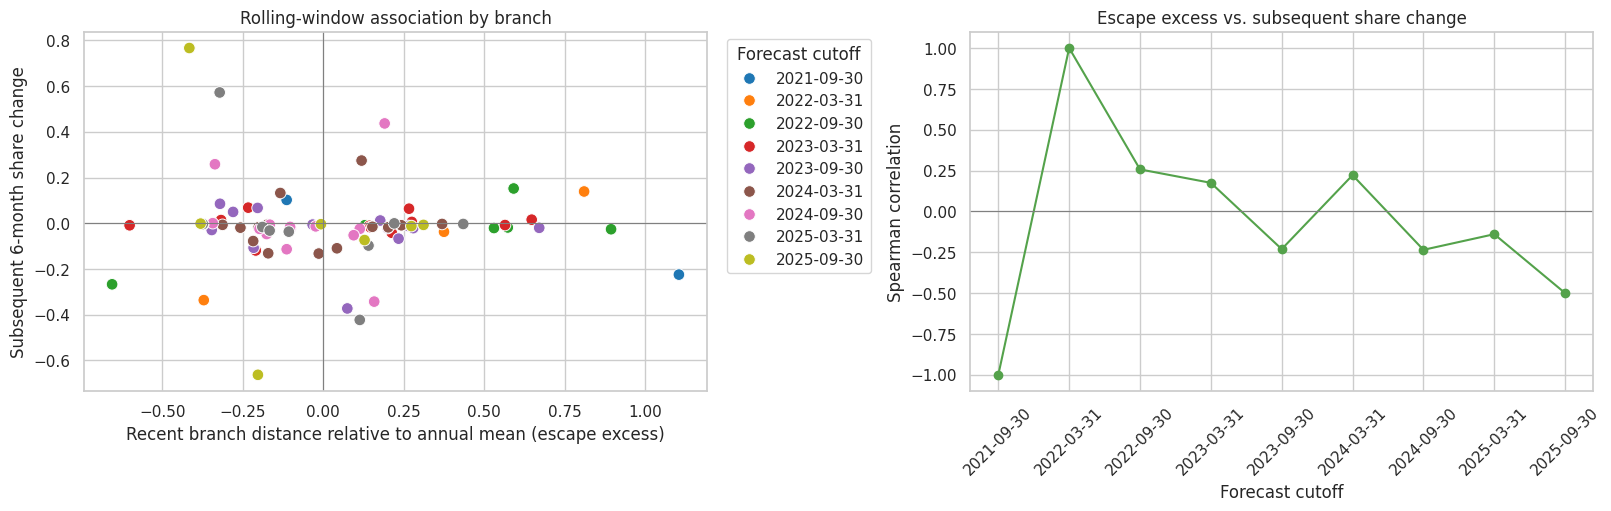

,forecast_cutoff,actual_next_top1,persistence_top1,escape_top1,escape_hit,persistence_hit
0,2021-09-30,B,B,C.1,False,True
1,2022-03-31,C.1,B,C.1,True,False
2,2022-09-30,C.1,C.1,C.1.4,False,True
3,2023-03-31,C.1,C.1,C.1.3,False,True
4,2023-09-30,C.1.9,C.1,C.1.3,False,False
5,2024-03-31,C.1.9,C.1.9,C.1.7.1,False,True
6,2024-09-30,C.1.9.3,C.1.9,C.1.9.3,True,False
7,2025-03-31,D.3.1,C.1.9.3,C.1.9.2,False,False
8,2025-09-30,D.3.1.1,D.3.1,D.5,False,False


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
plot_data = branch_detail.dropna(subset=['escape_excess']).copy()
sns.scatterplot(data=plot_data, x='escape_excess', y='share_change', hue='forecast_cutoff', palette='tab10', s=70, ax=axes[0])
axes[0].axhline(0, color='grey', lw=.8)
axes[0].axvline(0, color='grey', lw=.8)
axes[0].set(xlabel='Recent branch distance relative to annual mean (escape excess)', ylabel='Subsequent 6-month share change', title='Rolling-window association by branch')
axes[0].legend(title='Forecast cutoff', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].plot(metrics.forecast_cutoff, metrics.escape_vs_share_change_spearman, marker='o', color='#54A24B')
axes[1].axhline(0, color='grey', lw=.8)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set(xlabel='Forecast cutoff', ylabel='Spearman correlation', title='Escape excess vs. subsequent share change')
plt.show()

hits = (metrics[['forecast_cutoff', 'actual_next_top1', 'persistence_top1', 'escape_top1']]
        .assign(escape_hit=lambda d: d.actual_next_top1.eq(d.escape_top1),
                persistence_hit=lambda d: d.actual_next_top1.eq(d.persistence_top1)))
display(hits)

## 4. 分段 softmax 竞争模型（数学原型）

对每个 14 天频率向量 (p_t)，先用伪计数平滑，并转为中心对数比状态：

\[z_{t,k}=\log p_{t,k}-\frac{1}{K}\sum_j\log p_{t,j}\] 

在近期稳定竞争段中，假设 (z_t=z_{t-1}+v+\epsilon_t)。模型在最近 26 个非空 bin 内寻找前后状态均值差最大的断点，仅用断点后的数据以指数加权 ridge 回归估计局部速度 (v)，并采用阻尼外推：

\[\hat z_{T+h}=z_T+v\sum_{r=0}^{h-1}\phi^r,\qquad \hat p_{T+h}=\operatorname{softmax}(\hat z_{T+h})\] 

这是一种可解释的变点状态空间近似。它不能预测截止点之后首次出现的全新分支；这些分支在严格回测中按预测概率 0 处理。

In [ ]:
from src.h1n1_benchmarks import (
    DEFAULT_HALF_YEAR_WINDOWS,
    build_window_aligned_counts,
    evaluate_frequency_forecast,
    run_six_model_backtest,
)
from src.model import ChangePointSoftmaxForecaster

# 固定的数学超参数；本节不使用测试窗口调参。
MODEL_KWARGS = dict(
    lookback_bins=26,
    min_regime_bins=5,
    pseudocount=0.5,
    decay=0.92,
    ridge=1.0,
    change_threshold=0.35,
    max_step_norm=0.18,
    trend_damping=0.85,
)

backtest_rows, diagnostic_rows = [], []
for window_start, window_end in sorted(DEFAULT_HALF_YEAR_WINDOWS[:-3]):
    counts, _, horizon = build_window_aligned_counts(
        records, window_start=window_start, window_end=window_end
    )
    cutoff = pd.Timestamp(window_start) - pd.Timedelta(days=1)
    baseline_predictions, _, _, actual, _ = run_six_model_backtest(
        counts, cutoff=cutoff, horizon_bins=horizon
    )
    model = ChangePointSoftmaxForecaster(**MODEL_KWARGS)
    competition_prediction = model.predict(
        counts.loc[counts.index <= cutoff], horizon=len(actual), future_index=actual.index
    )
    diagnostics = model.last_diagnostics
    diagnostic_rows.append({
        'forecast_cutoff': cutoff.date().isoformat(),
        'change_point': diagnostics.change_point,
        'regime_start': diagnostics.regime_start,
        'change_score': diagnostics.change_score,
        'regime_bins': diagnostics.regime_bins,
        'slope_norm': diagnostics.slope_norm,
    })
    for name, prediction in {
        'C-B2': baseline_predictions['C-B2'],
        'Change-point softmax': competition_prediction,
    }.items():
        metric = evaluate_frequency_forecast(actual, prediction).to_dict()
        backtest_rows.append({
            'forecast_cutoff': cutoff.date().isoformat(),
            'model': name,
            **metric,
            'top1_accuracy': (prediction.idxmax(axis=1) == actual.idxmax(axis=1)).mean(),
        })

competition_detail = pd.DataFrame(backtest_rows)
competition_summary = (competition_detail.groupby('model', as_index=False)
    .agg(windows=('forecast_cutoff', 'nunique'), mean_MAE=('MAE', 'mean'),
         mean_RMSE=('RMSE', 'mean'), mean_TVD=('mean_TVD', 'mean'),
         mean_JSD=('mean_JSD', 'mean'), mean_top1_accuracy=('top1_accuracy', 'mean'))
    .sort_values('mean_TVD', ignore_index=True))
competition_diagnostics = pd.DataFrame(diagnostic_rows)

display(competition_summary.style.format({
    'mean_MAE': '{:.4f}', 'mean_RMSE': '{:.4f}', 'mean_TVD': '{:.4f}',
    'mean_JSD': '{:.4f}', 'mean_top1_accuracy': '{:.1%}',
}))


In [ ]:
tvd_by_cutoff = competition_detail.pivot(
    index='forecast_cutoff', columns='model', values='mean_TVD'
)
tvd_by_cutoff['Change-point softmax − C-B2'] = (
    tvd_by_cutoff['Change-point softmax'] - tvd_by_cutoff['C-B2']
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
long_tvd = tvd_by_cutoff[['C-B2', 'Change-point softmax']].reset_index().melt(
    id_vars='forecast_cutoff', var_name='model', value_name='mean_TVD'
)
sns.lineplot(data=long_tvd, x='forecast_cutoff', y='mean_TVD', hue='model', marker='o', ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set(xlabel='Forecast cutoff', ylabel='Mean TVD', title='Rolling distribution error (lower is better)')
axes[1].bar(tvd_by_cutoff.index, tvd_by_cutoff['Change-point softmax − C-B2'], color='#E45756')
axes[1].axhline(0, color='black', lw=.8)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set(xlabel='Forecast cutoff', ylabel='Δ TVD', title='Change-point softmax relative to C-B2')
plt.show()

display(tvd_by_cutoff.style.format('{:.4f}'))
display(competition_diagnostics.style.format({'change_score': '{:.3f}', 'slope_norm': '{:.3f}'}))
